# Iteration 3 (Updated): Webcam Domain Adaptation and Fine-Tuning

This updated notebook keeps the existing Iteration 3 architecture, then evaluates and adapts it using the new `ValidationSet` collected from webcam conditions.


## What problem from the previous model are we solving, and how do we know it improved?

The previous model was trained mostly on the main dataset distribution, but deployment showed domain mismatch on real webcam input (unstable and misinterpreted labels).

This update solves that by:
1. Evaluating the current model directly on the webcam `ValidationSet` (baseline).
2. Fine-tuning lightly using a **train split of webcam data** plus original training data.
3. Comparing before vs after on a **held-out webcam eval split** that is not used for training.

We consider improvement valid only if held-out webcam metrics improve (accuracy/macro-F1/confusion behavior), not just training loss.


In [7]:
import os

# Toggle this flag:
# True  -> try DirectML GPU (adapter 0 only)
# False -> force CPU mode for maximum stability
USE_GPU = True

if USE_GPU:
    os.environ.pop('CUDA_VISIBLE_DEVICES', None)
    os.environ['DML_VISIBLE_DEVICES'] = '0'  # Avoid multi-adapter duplicate-kernel conflicts
else:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

from pathlib import Path
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
WEBCAM_TUNE_SPLIT = 0.7
WEBCAM_TUNE_TRAIN_SPLIT = 0.8
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)
print('USE_GPU:', USE_GPU)


TensorFlow: 2.10.0
USE_GPU: True


In [8]:
# Runtime device config
if not USE_GPU:
    try:
        tf.config.set_visible_devices([], 'GPU')
    except Exception as error:
        print('GPU visibility already fixed:', error)
    print('CPU mode active. Visible GPUs:', tf.config.get_visible_devices('GPU'))
else:
    print('GPU mode requested. Visible GPUs:', tf.config.get_visible_devices('GPU'))


GPU mode requested. Visible GPUs: []


In [9]:
def find_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path('C:/Users/user/Documents/GitHub/behavior-detection/DLProject'),
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/DLProject'),
    ]
    for candidate in candidates:
        if (candidate / 'Code').exists() and (candidate / 'Dataset').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find project root containing Code/ and Dataset/.')


def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def extract_group_key(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    chunk_id = int(match.group(1)) // GROUP_CHUNK_SIZE if match else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'


def build_sequence_split_lists(dataset_root: Path, class_names, val_split: float = DATASET_VAL_SPLIT):
    train_paths, train_labels, val_paths, val_labels = [], [], [], []
    split_summary = []

    for class_index, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)

        grouped_files = {}
        for file_path in class_files:
            group_key = extract_group_key(file_path)
            grouped_files.setdefault(group_key, []).append(str(file_path))

        ordered_groups = sorted(grouped_files.items(), key=lambda item: item[0])
        val_group_count = max(1, int(round(len(ordered_groups) * val_split)))
        val_group_keys = {group_key for group_key, _ in ordered_groups[-val_group_count:]}

        class_train = 0
        class_val = 0
        for group_key, grouped_paths in ordered_groups:
            if group_key in val_group_keys:
                val_paths.extend(grouped_paths)
                val_labels.extend([class_index] * len(grouped_paths))
                class_val += len(grouped_paths)
            else:
                train_paths.extend(grouped_paths)
                train_labels.extend([class_index] * len(grouped_paths))
                class_train += len(grouped_paths)

        split_summary.append({
            'class_name': class_name,
            'groups': len(ordered_groups),
            'train_images': class_train,
            'val_images': class_val,
        })

    return train_paths, train_labels, val_paths, val_labels, split_summary


def load_folder_paths_labels(root: Path, class_names):
    paths, labels = [], []
    counts = {}
    for class_index, class_name in enumerate(class_names):
        class_dir = root / class_name
        files = sorted([p for p in class_dir.glob('*.jpg') if p.is_file()], key=natural_key)
        counts[class_name] = len(files)
        paths.extend([str(p) for p in files])
        labels.extend([class_index] * len(files))
    return paths, labels, counts


def stratified_split(paths, labels, train_fraction, seed=SEED):
    rng = np.random.default_rng(seed)
    paths = np.array(paths)
    labels = np.array(labels)

    train_indices, test_indices = [], []
    for label in np.unique(labels):
        idx = np.where(labels == label)[0]
        rng.shuffle(idx)
        split_point = max(1, int(round(len(idx) * train_fraction)))
        split_point = min(split_point, len(idx) - 1) if len(idx) > 1 else len(idx)
        train_indices.extend(idx[:split_point].tolist())
        test_indices.extend(idx[split_point:].tolist())

    train_indices = np.array(train_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)

    return (
        paths[train_indices].tolist(), labels[train_indices].tolist(),
        paths[test_indices].tolist(), labels[test_indices].tolist(),
    )


def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(paths, labels, training=False):
    path_arr = np.array(paths)
    label_arr = np.array(labels, dtype=np.int32)

    if training and len(path_arr) > 0:
        rng = np.random.default_rng(SEED)
        order = rng.permutation(len(path_arr))
        path_arr = path_arr[order]
        label_arr = label_arr[order]

    ds = tf.data.Dataset.from_tensor_slices((path_arr, label_arr))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)



def build_model(num_classes, base_trainable=False):
    # Identity augmentation for DirectML stability
    data_augmentation = keras.Sequential([], name='data_augmentation')

    base_model = keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights=None,
    )
    base_model.trainable = base_trainable

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model


def evaluate_on_dataset(model, ds, y_true, class_names, title_prefix='Evaluation', cmap='Blues'):
    y_prob = model.predict(ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap=cmap)
    plt.title(f'{title_prefix} Confusion Matrix')
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
    plt.tight_layout()

    print(f'{title_prefix} Accuracy: {acc:.4f}')
    print(f'{title_prefix} Macro-F1: {macro_f1:.4f}')
    print(f'{title_prefix} Weighted-F1: {weighted_f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'y_pred': y_pred,
    }


In [10]:
PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / 'Dataset'
VALIDATION_ROOT = PROJECT_ROOT / 'ValidationSet'
MODEL_INPUT_PATH = PROJECT_ROOT / 'Code' / 'final_proctor_model.h5'
BEST_FINE_TUNE_PATH = PROJECT_ROOT / 'Code' / 'best_final_proctor_model_finetune.h5'
MODEL_OUTPUT_PATH = PROJECT_ROOT / 'Code' / 'final_proctor_model.h5'

CLASS_NAMES = sorted([p.name for p in DATASET_ROOT.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print('Project root:', PROJECT_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Validation root:', VALIDATION_ROOT)
print('Input model:', MODEL_INPUT_PATH)
print('Output model:', MODEL_OUTPUT_PATH)
print('Classes:', CLASS_NAMES)

train_paths, train_labels, val_paths, val_labels, split_summary = build_sequence_split_lists(DATASET_ROOT, CLASS_NAMES)
print() 
print('Main dataset split summary (sequence-aware):')
for row in split_summary:
    print(row)

webcam_paths_all, webcam_labels_all, webcam_counts = load_folder_paths_labels(VALIDATION_ROOT, CLASS_NAMES)
print()
print('ValidationSet counts by class:')
for k, v in webcam_counts.items():
    print(f'{k}: {v}')

if min(webcam_counts.values()) < 5:
    print()
    print('Warning: Some classes have very few samples. Fine-tuning may be unstable.')

# webcam_all -> webcam_tune + webcam_eval (held out)
webcam_tune_paths, webcam_tune_labels, webcam_eval_paths, webcam_eval_labels = stratified_split(
    webcam_paths_all, webcam_labels_all, train_fraction=WEBCAM_TUNE_SPLIT, seed=SEED
)

# webcam_tune -> webcam_tune_train + webcam_tune_val (for callbacks)
webcam_tune_train_paths, webcam_tune_train_labels, webcam_tune_val_paths, webcam_tune_val_labels = stratified_split(
    webcam_tune_paths, webcam_tune_labels, train_fraction=WEBCAM_TUNE_TRAIN_SPLIT, seed=SEED + 1
)

print()
print('Webcam split sizes:')
print('webcam_tune_train:', len(webcam_tune_train_paths))
print('webcam_tune_val  :', len(webcam_tune_val_paths))
print('webcam_eval      :', len(webcam_eval_paths), '<- held-out final webcam evaluation')

combined_train_paths = train_paths + webcam_tune_train_paths
combined_train_labels = train_labels + webcam_tune_train_labels

base_val_ds = make_dataset(val_paths, val_labels, training=False)
combined_train_ds = make_dataset(combined_train_paths, combined_train_labels, training=True)
webcam_tune_val_ds = make_dataset(webcam_tune_val_paths, webcam_tune_val_labels, training=False)
webcam_eval_ds = make_dataset(webcam_eval_paths, webcam_eval_labels, training=False)


Project root: C:\Users\user\Documents\GitHub\behavior-detection\DLProject
Dataset root: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Dataset
Validation root: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\ValidationSet
Input model: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Code\final_proctor_model.h5
Output model: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Code\final_proctor_model.h5
Classes: ['distracted', 'fatigue', 'focused', 'listening', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']

Main dataset split summary (sequence-aware):
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 64, 'train_images': 982, 'val_images': 250}
{'class_name': 'listening', 'groups': 82, 'train_images': 1313, 'val_images': 313}
{'class_name': 'raise_hand', 'groups': 54, 'train_ima

Baseline (Before Fine-Tune) Accuracy: 0.2182
Baseline (Before Fine-Tune) Macro-F1: 0.1558
Baseline (Before Fine-Tune) Weighted-F1: 0.1482
                  precision    recall  f1-score   support

      distracted     0.2059    1.0000    0.3415         7
         fatigue     0.2857    0.2857    0.2857         7
         focused     0.0000    0.0000    0.0000         7
       listening     0.0000    0.0000    0.0000         8
      raise_hand     0.5000    0.2000    0.2857         5
        sleeping     0.4000    0.2857    0.3333         7
using_smartphone     0.0000    0.0000    0.0000         7
 writing_reading     0.0000    0.0000    0.0000         7

        accuracy                         0.2182        55
       macro avg     0.1739    0.2214    0.1558        55
    weighted avg     0.1589    0.2182    0.1482        55



c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\.venv310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

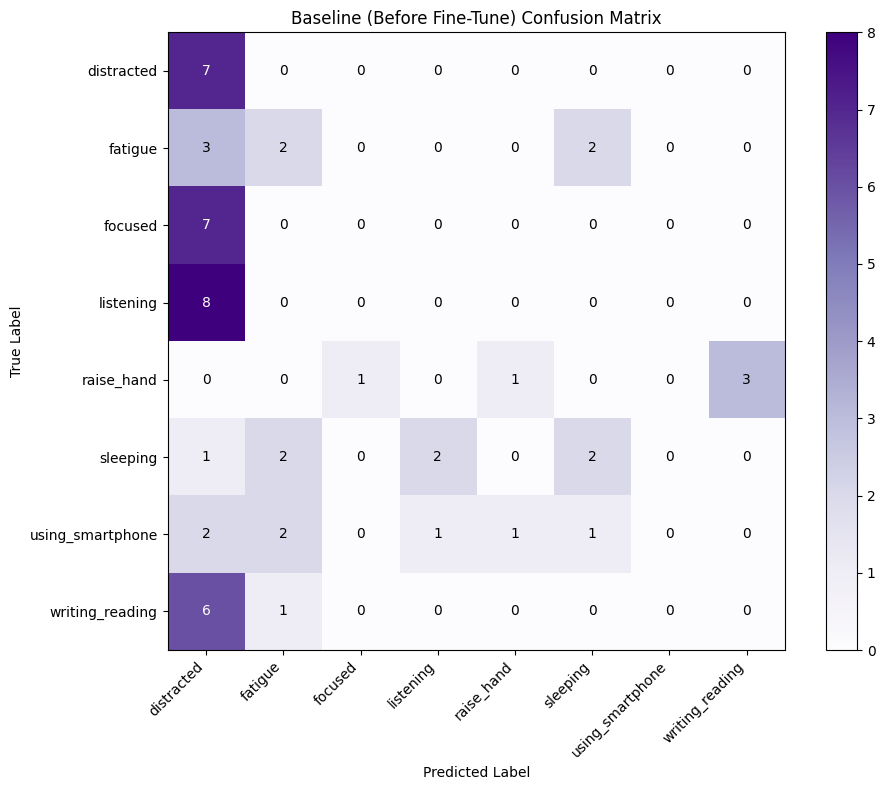

In [11]:
# Baseline: current deployed model on held-out webcam eval split
baseline_model, _ = build_model(NUM_CLASSES, base_trainable=False)
baseline_model.load_weights(MODEL_INPUT_PATH)

baseline_metrics = evaluate_on_dataset(
    baseline_model,
    webcam_eval_ds,
    np.array(webcam_eval_labels),
    CLASS_NAMES,
    title_prefix='Baseline (Before Fine-Tune)',
    cmap='Purples'
)


In [12]:
# Fine-tune setup: load existing weights, unfreeze only top MobileNetV2 blocks (except BatchNorm)
fine_tune_model, base_model = build_model(NUM_CLASSES, base_trainable=False)
fine_tune_model.load_weights(MODEL_INPUT_PATH)

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

fine_tune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(BEST_FINE_TUNE_PATH, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
]

history = fine_tune_model.fit(
    combined_train_ds,
    validation_data=webcam_tune_val_ds,
    epochs=15,
    callbacks=callbacks,
)

best_epoch = int(np.argmin(history.history['val_loss']))
print('Best fine-tune epoch:', best_epoch + 1)
print('Best val_loss:', round(float(history.history['val_loss'][best_epoch]), 4))
print('Best val_accuracy:', round(float(history.history['val_accuracy'][best_epoch]), 4))


# Ensure best checkpoint weights are loaded before evaluation
try:
    fine_tune_model.load_weights(BEST_FINE_TUNE_PATH)
    print(f'Loaded best fine-tune weights from: {BEST_FINE_TUNE_PATH}')
except Exception as error:
    print('Could not load best checkpoint weights; using in-memory EarlyStopping-restored weights:', error)


Epoch 1/15
219/219 [==============================] - ETA: 0s - loss: 0.1265 - accuracy: 0.9758
Epoch 1: val_loss improved from inf to 1.54347, saving model to C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Code\best_final_proctor_model_finetune.h5
219/219 [==============================] - 78s 349ms/step - loss: 0.1265 - accuracy: 0.9758 - val_loss: 1.5435 - val_accuracy: 0.4138 - lr: 1.0000e-05
Epoch 2/15
219/219 [==============================] - ETA: 0s - loss: 0.0847 - accuracy: 0.9850
Epoch 2: val_loss improved from 1.54347 to 1.06542, saving model to C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Code\best_final_proctor_model_finetune.h5
219/219 [==============================] - 69s 314ms/step - loss: 0.0847 - accuracy: 0.9850 - val_loss: 1.0654 - val_accuracy: 0.5862 - lr: 1.0000e-05
Epoch 3/15
219/219 [==============================] - ETA: 0s - loss: 0.0638 - accuracy: 0.9904
Epoch 3: val_loss improved from 1.06542 to 0.77353, saving model to C:\Use

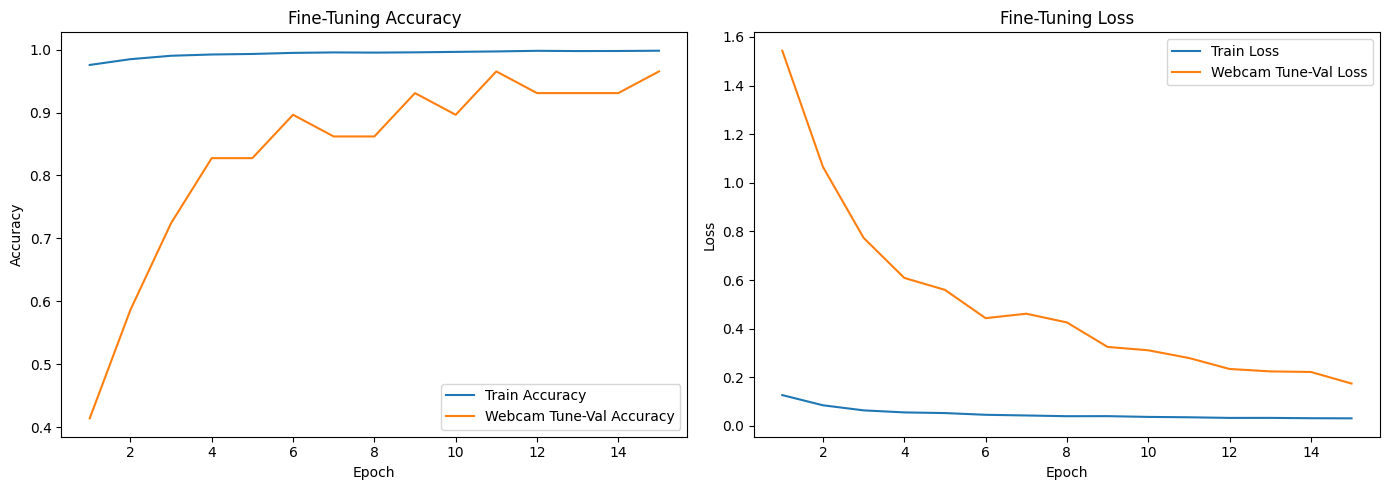

In [13]:
# Fine-tune curves
hist = history.history
epochs = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, hist['accuracy'], label='Train Accuracy')
plt.plot(epochs, hist['val_accuracy'], label='Webcam Tune-Val Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, hist['loss'], label='Train Loss')
plt.plot(epochs, hist['val_loss'], label='Webcam Tune-Val Loss')
plt.title('Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()


After Fine-Tune (Held-Out Webcam Eval) Accuracy: 0.8364
After Fine-Tune (Held-Out Webcam Eval) Macro-F1: 0.8506
After Fine-Tune (Held-Out Webcam Eval) Weighted-F1: 0.8444
                  precision    recall  f1-score   support

      distracted     0.8750    1.0000    0.9333         7
         fatigue     1.0000    0.8571    0.9231         7
         focused     0.5556    0.7143    0.6250         7
       listening     0.5556    0.6250    0.5882         8
      raise_hand     1.0000    0.8000    0.8889         5
        sleeping     1.0000    0.8571    0.9231         7
using_smartphone     1.0000    0.8571    0.9231         7
 writing_reading     1.0000    1.0000    1.0000         7

        accuracy                         0.8364        55
       macro avg     0.8733    0.8388    0.8506        55
    weighted avg     0.8629    0.8364    0.8444        55


Before vs After (held-out webcam eval):
Accuracy  : 0.2182 -> 0.8364
Macro-F1  : 0.1558 -> 0.8506
Weighted-F1: 0.1482 -> 0.8444


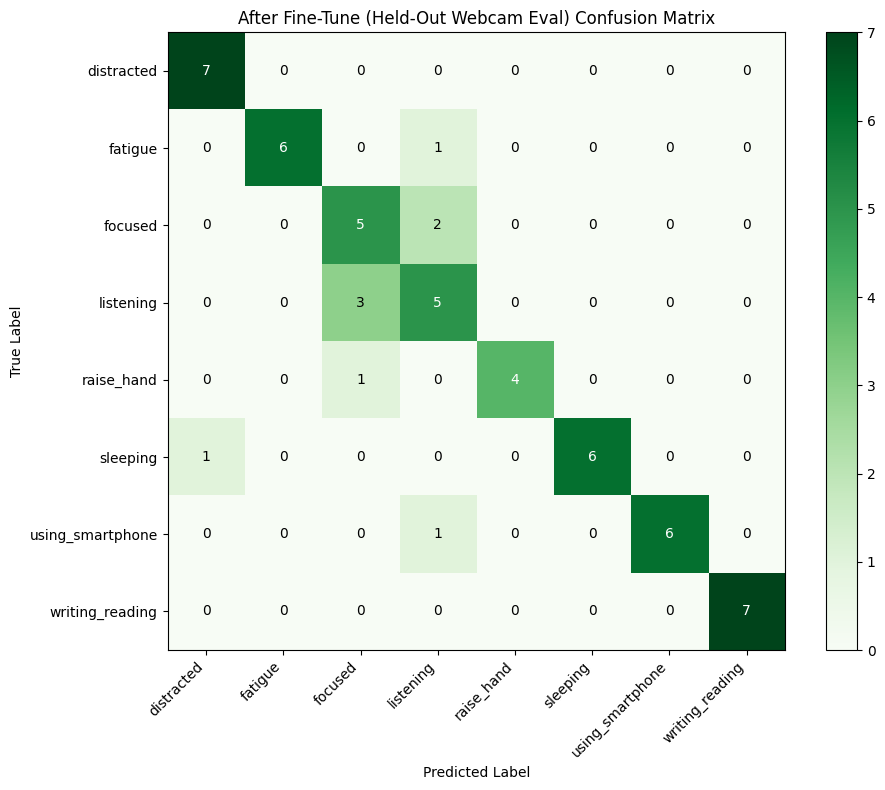

In [14]:
# Evaluate fine-tuned model on held-out webcam eval split
after_metrics = evaluate_on_dataset(
    fine_tune_model,
    webcam_eval_ds,
    np.array(webcam_eval_labels),
    CLASS_NAMES,
    title_prefix='After Fine-Tune (Held-Out Webcam Eval)',
    cmap='Greens'
)

print('\nBefore vs After (held-out webcam eval):')
print(f"Accuracy  : {baseline_metrics['accuracy']:.4f} -> {after_metrics['accuracy']:.4f}")
print(f"Macro-F1  : {baseline_metrics['macro_f1']:.4f} -> {after_metrics['macro_f1']:.4f}")
print(f"Weighted-F1: {baseline_metrics['weighted_f1']:.4f} -> {after_metrics['weighted_f1']:.4f}")


In [15]:
# Save final deployment model (overwrite final_proctor_model.h5 only if after metrics are better)
improved = (after_metrics['macro_f1'] >= baseline_metrics['macro_f1']) and (after_metrics['accuracy'] >= baseline_metrics['accuracy'])

if improved:
    fine_tune_model.save(MODEL_OUTPUT_PATH)
    print(f'Improved model saved to: {MODEL_OUTPUT_PATH}')
else:
    print('Fine-tuned model did not improve both accuracy and macro-F1 on held-out webcam eval.')
    print('Keeping existing deployment model unchanged.')


Improved model saved to: C:\Users\user\Documents\GitHub\behavior-detection\DLProject\Code\final_proctor_model.h5


## Final Evidence Summary

This updated Iteration 3 notebook now includes:
1. Baseline evaluation on webcam-collected `ValidationSet`.
2. Light fine-tuning using original dataset + webcam tune-train split.
3. Before/after comparison on a held-out webcam eval split.
4. Safe export behavior that only overwrites deployment model when held-out webcam metrics improve.

If held-out webcam metrics improve, this is direct evidence that domain adaptation reduced deployment mismatch.
